# ##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.



### 1) Colab setup
Run this cell first in Google Colab.


In [59]:

# Colab setup
!pip -q install rarfile opencv-python-headless==4.10.0.84

import os
import cv2
import math
import random
import shutil
import rarfile
import zipfile
import datetime as dt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from collections import deque
from google.colab import files
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)


TensorFlow: 2.19.0
OpenCV: 4.10.0


In [60]:
!pip install rarfile

### 2) Download and extract UCF11 dataset

In [61]:

import os
import rarfile

DATASET_RAR = 'UCF11_updated_mpg.rar'
DATASET_URL = 'https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar'
EXTRACT_DIR = 'UCF11'

# Install unrar (needed in Colab)
!apt-get install -y unrar

# Download
if not os.path.exists(DATASET_RAR):
    !wget --no-check-certificate -O {DATASET_RAR} {DATASET_URL}
else:
    print(f'{DATASET_RAR} already exists.')

# Extract
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with rarfile.RarFile(DATASET_RAR) as rf:
        rf.extractall(EXTRACT_DIR)
    print('Extraction complete.')
else:
    print(f'{EXTRACT_DIR} already exists.')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 104 not upgraded.
UCF11_updated_mpg.rar already exists.
UCF11 already exists.


### 3) Inspect dataset structure

In [62]:

# Inspect extracted folders
for root, dirs, files_in_dir in os.walk(EXTRACT_DIR):
    print(root)
    print('  subfolders:', dirs[:5])
    print('  files:', files_in_dir[:3])
    print('-' * 60)
    # Print only first few levels to avoid too much output
    if root.count(os.sep) - EXTRACT_DIR.count(os.sep) >= 2:
        continue
    if root != EXTRACT_DIR:
        break


UCF11
  subfolders: ['UCF11_updated_mpg']
  files: []
------------------------------------------------------------
UCF11/UCF11_updated_mpg
  subfolders: ['soccer_juggling', 'walking', 'golf_swing', 'diving', 'volleyball_spiking']
  files: []
------------------------------------------------------------


### 4) Helper functions

In [63]:

VIDEO_EXTENSIONS = ('.avi', '.mp4', '.mov', '.mpg', '.mpeg', '.mkv')

def find_class_directories(base_dir):
    """
    Return a dict: {class_name: class_folder_path}
    Works even if the extracted archive contains one extra wrapper folder.
    """
    candidates = {}
    for root, dirs, files_in_dir in os.walk(base_dir):
        video_count = sum(1 for f in files_in_dir if f.lower().endswith(VIDEO_EXTENSIONS))
        if video_count > 0:
            class_name = os.path.basename(root)
            parent_name = os.path.basename(os.path.dirname(root))
            # In UCF11, videos are often inside class/group folders.
            # So if current folder looks like a group folder, use parent as class name.
            if parent_name and parent_name != os.path.basename(base_dir):
                candidates[parent_name] = os.path.dirname(root)
    return candidates


def get_video_paths_from_class(class_dir):
    paths = []
    for root, _, files_in_dir in os.walk(class_dir):
        for file_name in files_in_dir:
            if file_name.lower().endswith(VIDEO_EXTENSIONS):
                paths.append(os.path.join(root, file_name))
    return sorted(paths)


def show_random_video_frames(class_dirs, selected_classes, samples_per_class=3):
    plt.figure(figsize=(15, 12))
    plot_index = 1
    for class_name in selected_classes:
        video_paths = get_video_paths_from_class(class_dirs[class_name])
        chosen = random.sample(video_paths, min(samples_per_class, len(video_paths)))
        for video_path in chosen:
            video_reader = cv2.VideoCapture(video_path)
            success, frame = video_reader.read()
            video_reader.release()
            if not success:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (220, 160))
            plt.subplot(len(selected_classes), samples_per_class, plot_index)
            plt.imshow(frame)
            plt.title(class_name)
            plt.axis('off')
            plot_index += 1
    plt.tight_layout()
    plt.show()


### 5) Choose three classes

In [64]:
# ===== SETUP CELL =====
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

seed_constant = 27
image_height = 64
image_width = 64

Available classes: ['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


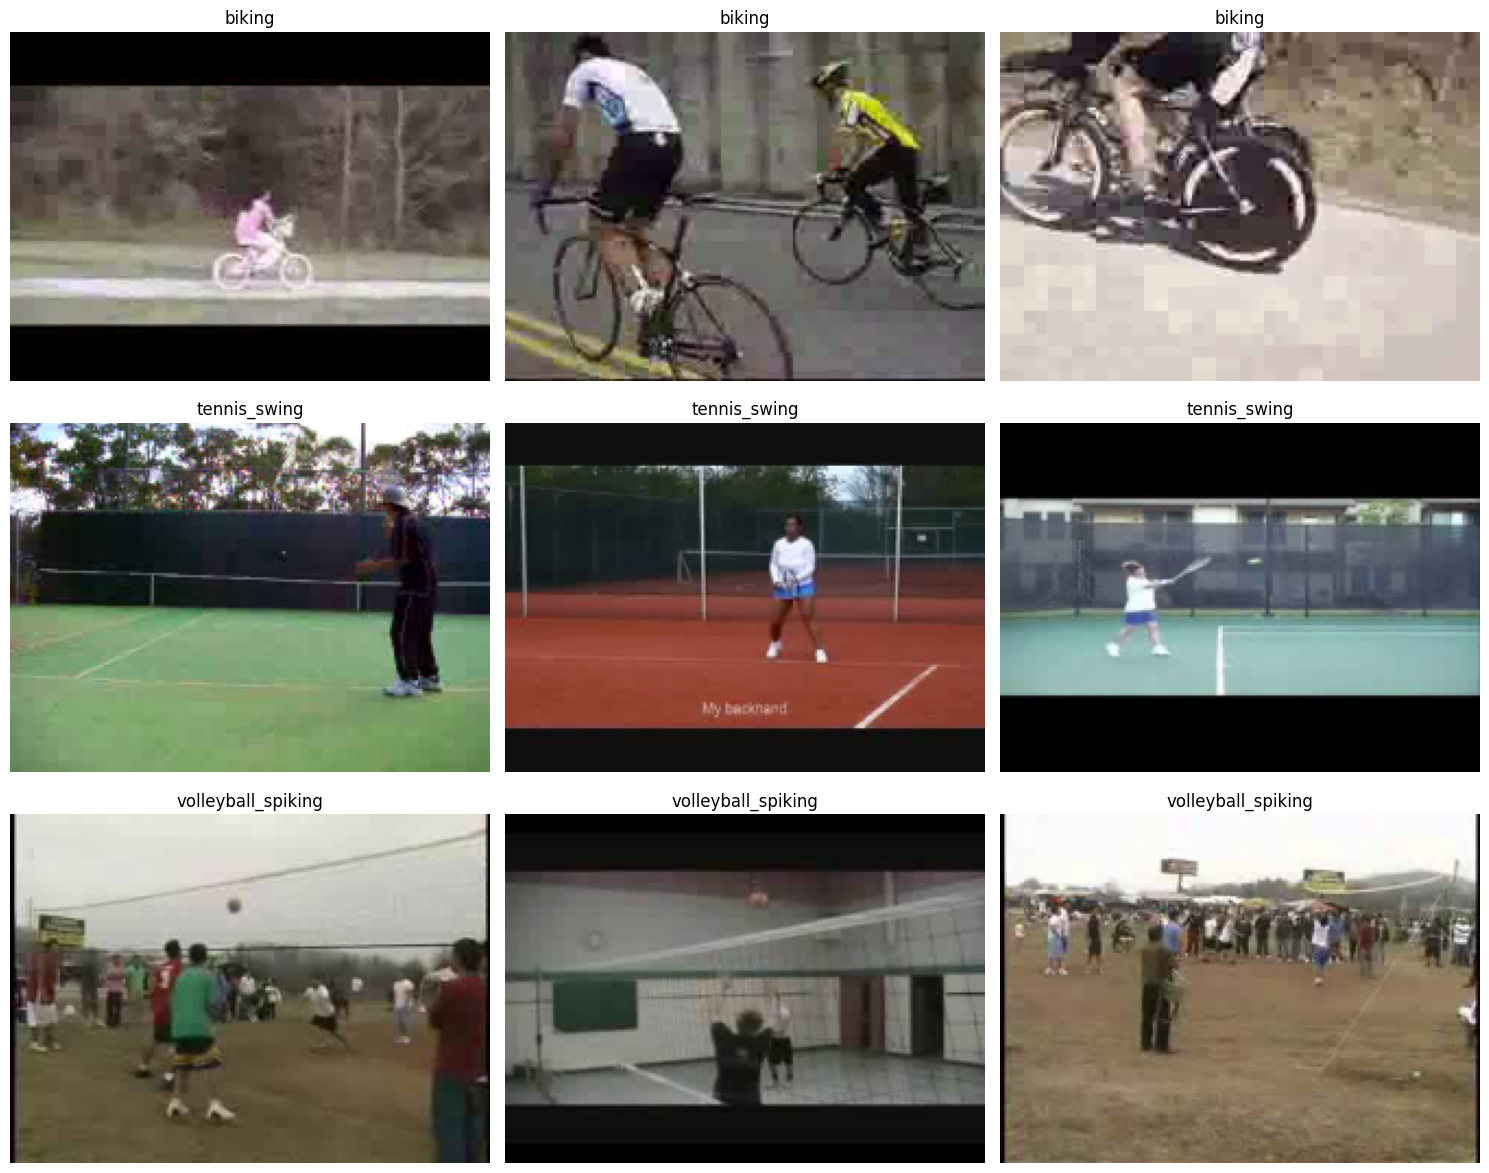

In [65]:

import matplotlib.pyplot as plt

class_dirs = find_class_directories(EXTRACT_DIR)
print('Available classes:', sorted(class_dirs.keys()))

# Chosen classes for the solved exercise
selected_classes = ['biking', 'tennis_swing', 'volleyball_spiking']

for cls in selected_classes:
    assert cls in class_dirs, f"Class '{cls}' not found. Available classes: {sorted(class_dirs.keys())}"

show_random_video_frames(class_dirs, selected_classes, samples_per_class=3)


### 6) Preprocess videos into frame dataset

In [66]:

image_height, image_width = 64, 64
max_frames_per_class = 2500
frames_per_video = 12         # sampled uniformly from each video


def frames_extraction(video_path, frames_per_video=12):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count == 0:
        video_reader.release()
        return frames_list

    skip_frames_window = max(int(video_frames_count / frames_per_video), 1)

    for frame_counter in range(frames_per_video):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()
        if not success:
            break
        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list


def create_dataset(selected_classes):
    temp_features = []
    features = []
    labels = []

    for class_index, class_name in enumerate(selected_classes):
        print(f'Extracting data for class: {class_name}')
        video_paths = get_video_paths_from_class(class_dirs[class_name])

        for video_path in video_paths:
            frames = frames_extraction(video_path, frames_per_video=frames_per_video)
            temp_features.extend(frames)

        sample_count = min(max_frames_per_class, len(temp_features))
        sampled_frames = random.sample(temp_features, sample_count)
        features.extend(sampled_frames)
        labels.extend([class_index] * sample_count)
        print(f'  collected frames: {len(temp_features)}, sampled: {sample_count}')
        temp_features.clear()

    features = np.asarray(features, dtype=np.float32)
    labels = np.array(labels)
    return features, labels

features, labels = create_dataset(selected_classes)
print('features shape:', features.shape)
print('labels shape:', labels.shape)


Extracting data for class: biking
  collected frames: 1740, sampled: 1740
Extracting data for class: tennis_swing
  collected frames: 2004, sampled: 2004
Extracting data for class: volleyball_spiking
  collected frames: 1392, sampled: 1392
features shape: (5136, 64, 64, 3)
labels shape: (5136,)


### 7) Split into train/test

In [67]:
seed_constant = 27

one_hot_encoded_labels = to_categorical(labels, num_classes=len(selected_classes))

features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant,
    stratify=labels
)


### 8) Create the model

In [68]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
def create_model(model_output_size):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(model_output_size, activation='softmax'))

    model.summary()
    return model

model = create_model(len(selected_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,939 (499.76 KB)

 Trainable params: 127,491 (498.01 KB)

 Non-trainable params: 448 (1.75 KB)

### 9) Compile and train

In [69]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=8,
    mode='min',
    restore_best_weights=True
)

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

model_training_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=20,
    batch_size=16,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)


Epoch 1/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8567 - loss: 0.3777 - val_accuracy: 0.3139 - val_loss: 5.3042
Epoch 2/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9577 - loss: 0.1234 - val_accuracy: 0.4051 - val_loss: 3.1750
Epoch 3/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9711 - loss: 0.0868 - val_accuracy: 0.6959 - val_loss: 0.9894
Epoch 4/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9842 - loss: 0.0499 - val_accuracy: 0.8297 - val_loss: 0.7834
Epoch 5/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9881 - loss: 0.0361 - val_accuracy: 0.7944 - val_loss: 0.5739
Epoch 6/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9866 - loss: 0.0388 - val_accuracy: 0.8796 - val_loss: 0.4004
Epoch 7/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9817 - loss: 0.0475 - val_accuracy: 0.7056 - val_loss: 0.9752
Epoch 8/20
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9900 - loss: 0.0334 - val_accuracy: 

### 10) Evaluate

In [70]:

model_evaluation_history = model.evaluate(features_test, labels_test)
print('Test loss:', model_evaluation_history[0])
print('Test accuracy:', model_evaluation_history[1])


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9990 - loss: 0.0025
Test loss: 0.0025280783884227276
Test accuracy: 0.9990272521972656


### 11) Plot training curves

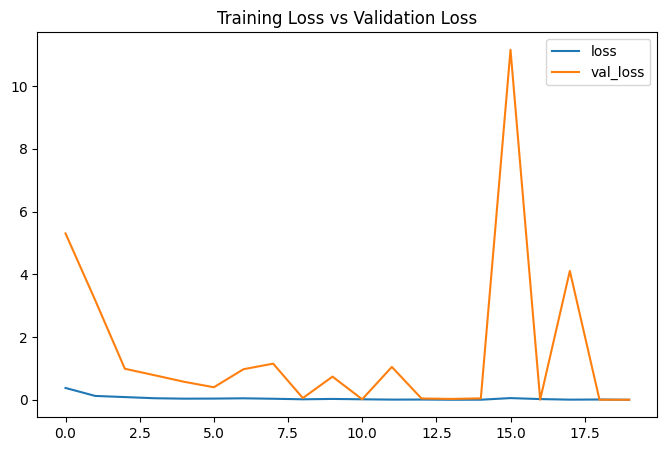

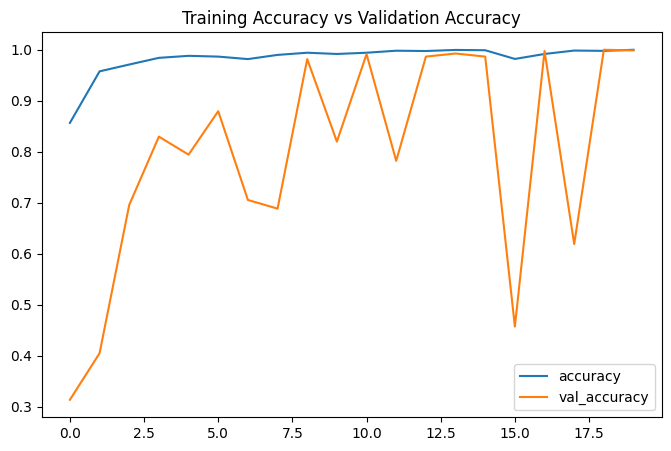

In [71]:

def plot_metric(metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    epochs = range(len(metric_value_1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metric_value_1, label=metric_name_1)
    plt.plot(epochs, metric_value_2, label=metric_name_2)
    plt.title(plot_name)
    plt.legend()
    plt.show()

plot_metric('loss', 'val_loss', 'Training Loss vs Validation Loss')
plot_metric('accuracy', 'val_accuracy', 'Training Accuracy vs Validation Accuracy')


### 12) Save the trained model with my name

In [72]:

student_name = 'Azzah Alghamdi'
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")


Model saved as Azzah Alghamdi_ucf11_model.h5



### 13) Validate on 3 external videos



In [73]:
def make_average_predictions(video_file_path, predictions_frames_count):
    predicted_labels_probabilities_np = np.zeros(
        (predictions_frames_count, model_output_size), dtype=float
    )

    video_reader       = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = video_frames_count // predictions_frames_count

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        _, frame = video_reader.read()

        resized_frame    = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
    sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    print(f"\nResults for: {video_file_path}")
    for predicted_label in sorted_indexes:
        predicted_class_name  = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS NAME: {predicted_class_name:<25} AVERAGED PROBABILITY: {predicted_probability:.2f}")

    video_reader.release()

In [75]:
converted_video_paths = []

for i in range(len(video_urls)):
    input_path = f"Youtube_Videos/video_{i}.mp4"
    output_path = f"Youtube_Videos/converted_{i}.mp4"
    os.system(f'ffmpeg -y -i "{input_path}" -c:v libx264 -pix_fmt yuv420p -c:a aac "{output_path}"')
    converted_video_paths.append(output_path)

print("Converted videos:", converted_video_paths)

Converted videos: ['Youtube_Videos/converted_0.mp4', 'Youtube_Videos/converted_1.mp4', 'Youtube_Videos/converted_2.mp4']


In [83]:
import cv2
import numpy as np
import os

# ===== IMPORTANT: make sure these already exist =====
# model
# selected_classes
# image_height
# image_width

# ===== STEP 1: create folder =====
os.makedirs("Videos", exist_ok=True)

# ===== STEP 2: download 3 videos (no YouTube, guaranteed working) =====
video_urls = [
    "https://filesamples.com/samples/video/mp4/sample_640x360.mp4",
    "https://filesamples.com/samples/video/mp4/sample_960x400_ocean_with_audio.mp4",
    "https://filesamples.com/samples/video/mp4/sample_1280x720_surfing_with_audio.mp4"
]

external_video_paths = []

for i, url in enumerate(video_urls):
    filename = f"Videos/video_{i}.mp4"
    !wget -q -O "{filename}" "{url}"
    external_video_paths.append(filename)

print("Downloaded videos:", external_video_paths)

# ===== STEP 3: check readability =====
for video_path in external_video_paths:
    cap = cv2.VideoCapture(video_path)
    ok, frame = cap.read()
    print(video_path, "readable:", ok)
    cap.release()

# ===== STEP 4: prediction function =====
def make_average_predictions(video_file_path, predictions_frames_count=40):
    predicted_labels_probabilities_np = np.zeros(
        (predictions_frames_count, len(selected_classes)), dtype=float
    )

    video_reader = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(video_frames_count // predictions_frames_count, 1)

    used_frames = 0

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities
        used_frames += 1

    video_reader.release()

    if used_frames == 0:
        print(f'Could not read frames from {video_file_path}')
        return None

    predicted_avg = predicted_labels_probabilities_np[:used_frames].mean(axis=0)
    sorted_indexes = np.argsort(predicted_avg)[::-1]

    print(f'\nVideo: {video_file_path}')
    for idx in sorted_indexes:
        print(f'  CLASS: {selected_classes[idx]:<20} PROB: {predicted_avg[idx]:.4f}')

    best_label = int(np.argmax(predicted_avg))
    print(f'  FINAL PREDICTION: {selected_classes[best_label]}')
    print('-' * 60)

    return selected_classes[best_label]

# ===== STEP 5: run predictions =====
for video_path in external_video_paths:
    make_average_predictions(video_path, predictions_frames_count=40)

Downloaded videos: ['Videos/video_0.mp4', 'Videos/video_1.mp4', 'Videos/video_2.mp4']
Videos/video_0.mp4 readable: True
Videos/video_1.mp4 readable: True
Videos/video_2.mp4 readable: True

Video: Videos/video_0.mp4
  CLASS: biking               PROB: 0.9999
  CLASS: volleyball_spiking   PROB: 0.0001
  CLASS: tennis_swing         PROB: 0.0000
  FINAL PREDICTION: biking
------------------------------------------------------------

Video: Videos/video_1.mp4
  CLASS: tennis_swing         PROB: 0.6297
  CLASS: volleyball_spiking   PROB: 0.2925
  CLASS: biking               PROB: 0.0778
  FINAL PREDICTION: tennis_swing
------------------------------------------------------------

Video: Videos/video_2.mp4
  CLASS: volleyball_spiking   PROB: 0.4153
  CLASS: tennis_swing         PROB: 0.2995
  CLASS: biking               PROB: 0.2852
  FINAL PREDICTION: volleyball_spiking
------------------------------------------------------------
